In [ ]:
import pandas as pd
df = pd.read_csv('/content/diabetes (1).csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [ ]:
df.shape

(768, 9)

In [ ]:
X = df.drop('Outcome',axis='columns')
Y = df[['Outcome']]

In [ ]:
df[['Outcome']].value_counts()

,count
Outcome,
0,500
1,268


In [ ]:
df['Outcome'].unique()

array([1, 0])

In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X,Y)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dmodel = DecisionTreeClassifier(max_depth=7)

In [ ]:
dmodel.fit(xtrain,ytrain)

DecisionTreeClassifier(max_depth=7)

In [ ]:
print(dmodel.score(xtrain,ytrain))
print(dmodel.score(xtest,ytest))

0.9027777777777778
0.7239583333333334


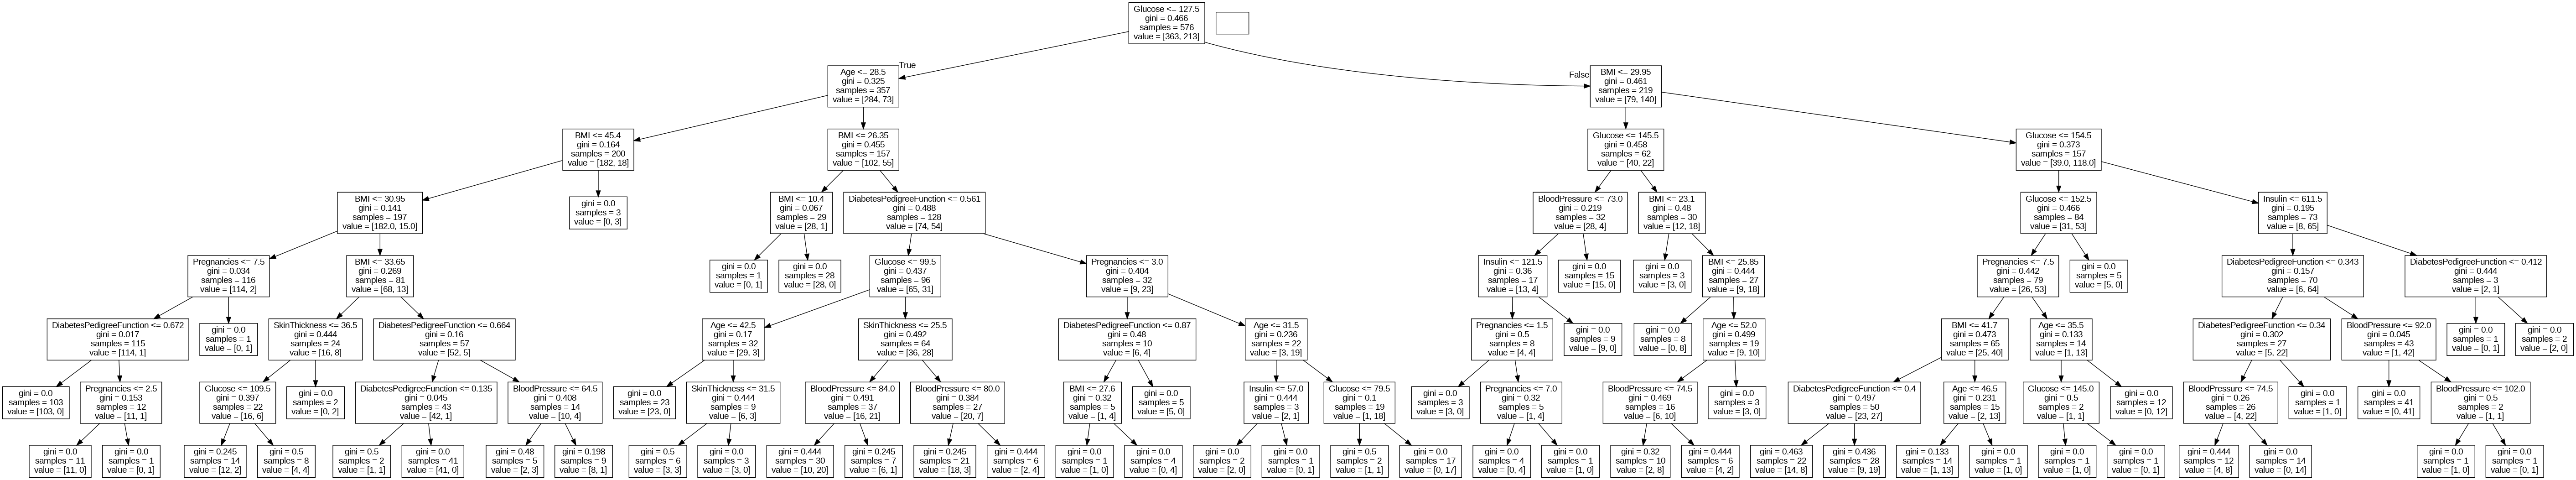

In [ ]:
from sklearn.tree import export_graphviz
from IPython.display import Image
import pydotplus

dot_data = export_graphviz(dmodel,feature_names=xtrain.columns)
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

In [ ]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix

In [ ]:
confusion_matrix(ytrain,dmodel.predict(xtrain))

array([[333,  30],
       [ 26, 187]])

In [ ]:
confusion_matrix(ytest,dmodel.predict(xtest))

array([[101,  36],
       [ 17,  38]])

Random Forest Classifier


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rmodel = RandomForestClassifier(n_estimators=50,max_depth=7)

rmodel.fit(xtrain,ytrain)

print(rmodel.score(xtrain,ytrain))
print(rmodel.score(xtest,ytest))

0.9461805555555556
0.7447916666666666


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
confusion_matrix(ytrain,rmodel.predict(xtrain))

array([[355,   8],
       [ 23, 190]])

In [ ]:
confusion_matrix(ytest,rmodel.predict(xtest))

array([[106,  31],
       [ 18,  37]])